In [38]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score)


In [39]:
df = pd.read_csv('insurance.csv')
display(df.info)

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [40]:
display(df.columns,df.dtypes)


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [41]:
display(((~df.isnull()).mean())*100)

age         100.0
sex         100.0
bmi         100.0
children    100.0
smoker      100.0
region      100.0
charges     100.0
dtype: float64

In [42]:
col = ['age','bmi','children','charges']
per_zeros = ((df[col] == 0).mean())*100
display(per_zeros)

age          0.000000
bmi          0.000000
children    42.899851
charges      0.000000
dtype: float64

C:\Users\romma\AppData\Local\Temp\ipykernel_22032\2377842502.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='children', y='charges', ax=axes[0,1], palette="muted")
C:\Users\romma\AppData\Local\Temp\ipykernel_22032\2377842502.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='charges', ax=axes[1,0], palette="magma")
C:\Users\romma\AppData\Local\Temp\ipykernel_22032\2377842502.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='charges', ax=axes[2,0], palette="cool")
C:\Users\rom

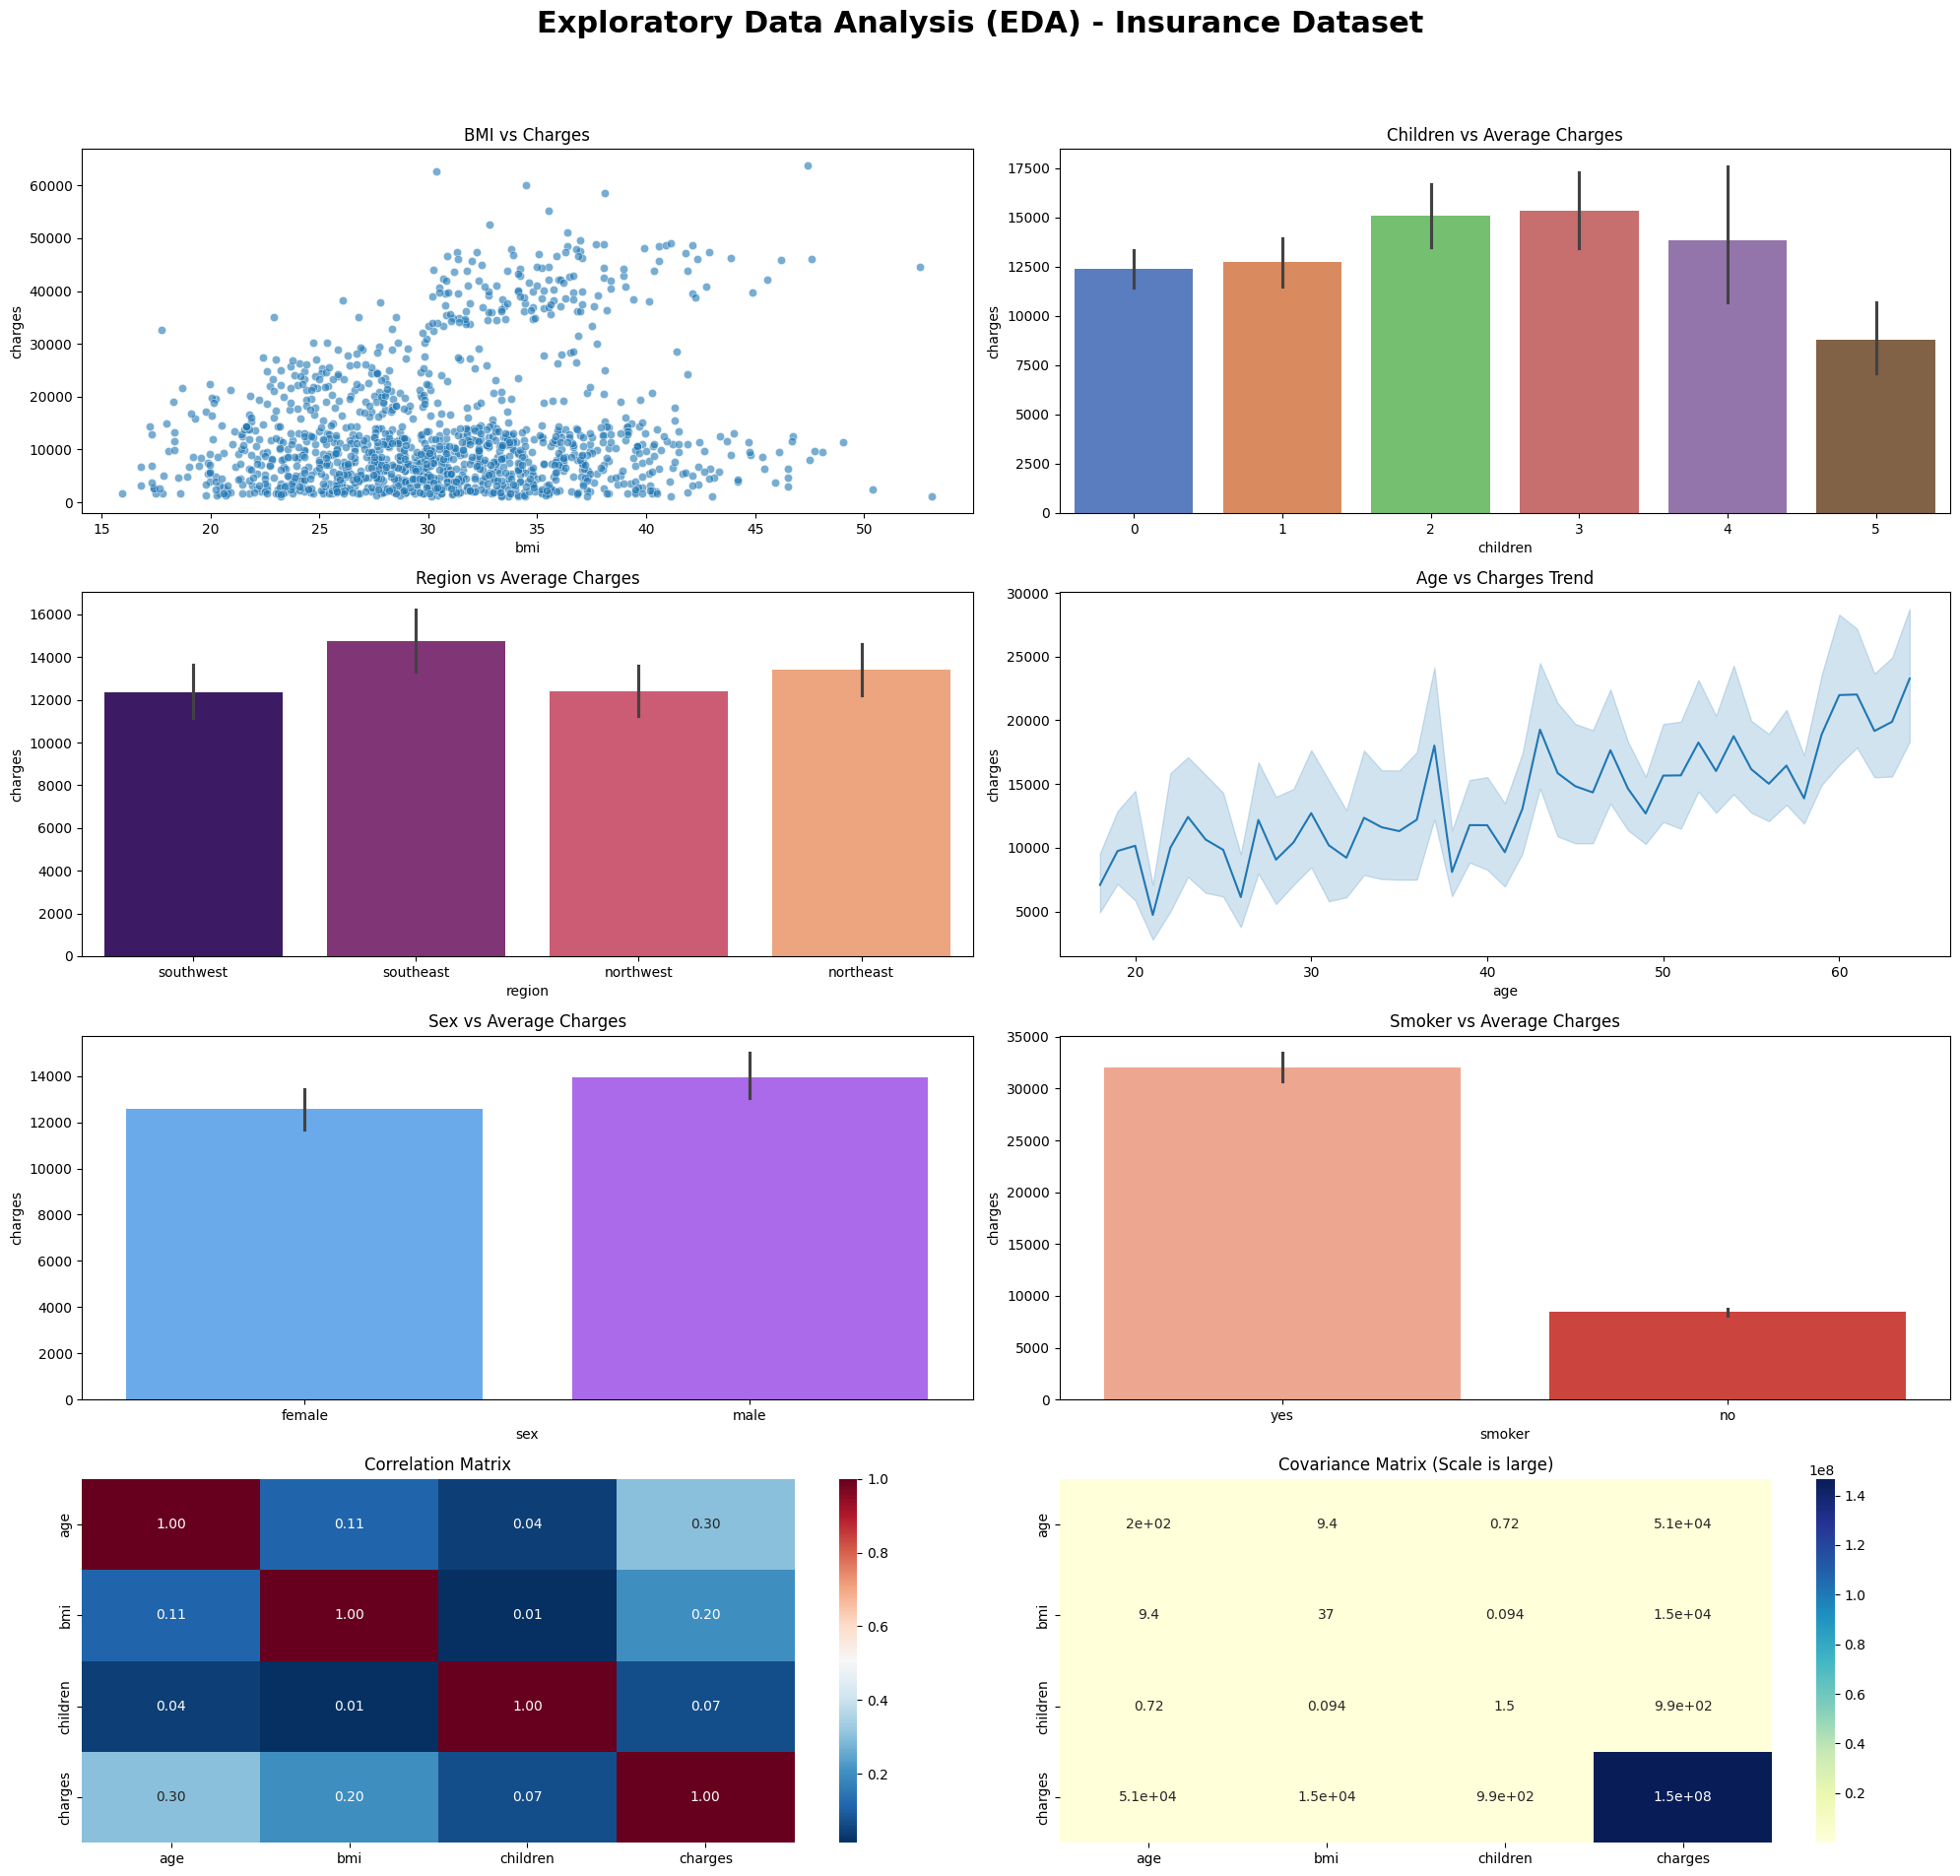

In [43]:

import seaborn as sns


# 1. Prep the Matrices (Numeric only)
df_nums = df.select_dtypes(include=np.number)
corr_matrix = df_nums.corr()
cov_matrix = np.cov(df_nums.T)
cov_df = pd.DataFrame(cov_matrix, index=df_nums.columns, columns=df_nums.columns)

fig, axes = plt.subplots(4, 2, figsize=(20, 20))

# --- ROW 0: Numerical Relationships ---
sns.scatterplot(data=df, x='bmi', y='charges', ax=axes[0,0], alpha=0.6)
axes[0,0].set_title("BMI vs Charges")

# Using barplot here calculates the MEAN charges for each number of children
sns.barplot(data=df, x='children', y='charges', ax=axes[0,1], palette="muted")
axes[0,1].set_title("Children vs Average Charges")

# --- ROW 1: Categorical Relationships ---
sns.barplot(data=df, x='region', y='charges', ax=axes[1,0], palette="magma")
axes[1,0].set_title("Region vs Average Charges")


sns.lineplot(data=df, x='age', y='charges', ax=axes[1,1])
axes[1,1].set_title("Age vs Charges Trend")

# --- ROW 2: Categorical Relationships ---
sns.barplot(data=df, x='sex', y='charges', ax=axes[2,0], palette="cool")
axes[2,0].set_title("Sex vs Average Charges")

# This is the one you were worried about!
sns.barplot(data=df, x='smoker', y='charges', ax=axes[2,1], palette="Reds")
axes[2,1].set_title("Smoker vs Average Charges")

# --- ROW 3: Matrices ---
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[3,0])
axes[3,0].set_title("Correlation Matrix")

sns.heatmap(cov_df, annot=True, cmap='YlGnBu', ax=axes[3,1]) 
axes[3,1].set_title("Covariance Matrix (Scale is large)")

fig.suptitle("Exploratory Data Analysis (EDA) - Insurance Dataset", fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exploratory Data Analysis (EDA)
Before building our regression models, we must understand the underlying patterns, distributions, and relationships within the insurance dataset.

- Technical Insights:
Target Variable Distribution: The scatter plots for Age vs Charges and BMI vs Charges reveal clear stratification. In Age vs Charges, we see three distinct "bands" of costs, suggesting that factors other than age (likely smoking status) drastically shift the base cost.

- Categorical Impact: 
The bar charts indicate that Smokers incur significantly higher charges than non-smokers. Region and Sex appear to have a more uniform distribution regarding total charges.

- Correlation Analysis: 
The Correlation Matrix highlights a moderate positive correlation (0.30) between Age and Charges. However, since correlation only captures linear relationships, the "Smoker" categorical variable (which we will encode next) is expected to be a much stronger predictor.

- Covariance:
 The Covariance Matrix shows how variables change together in their original scales, emphasizing the high variance in medical Charges.

## Data Preprocessing:
- Encoding Categorical Variables
Machine Learning models require numerical input. Since our dataset contains categorical variables (sex, smoker, region), we must transform them into a format the model can interpret.

- Decision Logic:
- One-Hot Encoding: We applied One-Hot Encoding to convert categorical labels into binary columns.

- Handling the Dummy Variable Trap: We used drop='first' to avoid Multicollinearity. For binary columns like sex and smoker, this reduces them to a single column (e.g., smoker_yes), where 0 represents the dropped category.

- Target Separation: We isolated charges into a df_target series to define our dependent variable (y) for the regression task, while keeping the independent variables (X) in the main dataframe.

C:\Users\romma\AppData\Local\Temp\ipykernel_22032\2726406756.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-Smokers', 'Smokers'], y=means, palette='viridis')


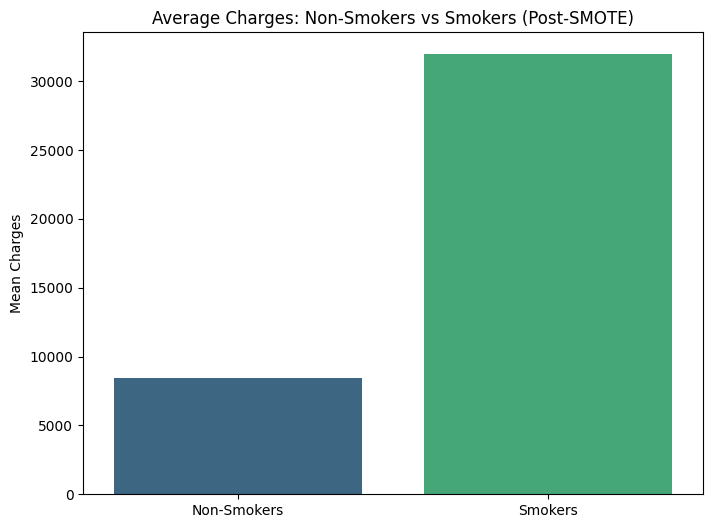

(2128, 11)

,age,bmi,children,sex_female,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest,smoker_no
0,19,27.900,0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,18,33.770,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,28,33.000,3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,33,22.705,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,32,28.880,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [44]:
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
import seaborn as sns

enc = OneHotEncoder(sparse_output=False,drop=None) # non to be droped as we need to over sample the non-smokers feature (check the EDA)
df_enc = enc.fit_transform(df[['sex','smoker','region']])
df_enc = pd.DataFrame(df_enc,columns = enc.get_feature_names_out(['sex','smoker','region']))
df = df.merge(df_enc, left_index=True, right_index=True)
df.drop(columns=['sex','smoker','region'], inplace=True)

sm = SMOTE(random_state=42)
x_dum , y_dum = sm.fit_resample(df.drop(columns='smoker_no'),df['smoker_no'])

df = pd.concat([x_dum,y_dum],axis=1)

plt.figure(figsize=(8, 6))

# You already calculated the two specific numbers here:
means = [df[df['smoker_no'] == 1]['charges'].mean(), 
         df[df['smoker_yes'] == 1]['charges'].mean()]

# Pass the 2 category names and the 2 calculated means
sns.barplot(x=['Non-Smokers', 'Smokers'], y=means, palette='viridis')

plt.title("Average Charges: Non-Smokers vs Smokers (Post-SMOTE)")
plt.ylabel("Mean Charges")
plt.show()

df_target = df['charges']
df.drop(columns='charges',inplace=True)

display(df.shape)
display(df.head())

## Feature Engineering: Handling Class Imbalance via SMOTE
After conducting the initial Exploratory Data Analysis (EDA), a significant imbalance was observed in the smoker feature. To ensure the regression model does not become biased toward the majority class (non-smokers), SMOTE (Synthetic Minority Over-sampling Technique) was applied.

- Observation & Justification
Distribution Shift: Before resampling, the dataset was heavily skewed toward non-smokers. This often leads to a model that "under-predicts" high-cost insurance claims because it lacks sufficient smoker-related examples.

- Synthetic Generation: SMOTE was used to generate synthetic smoker instances by interpolating between existing minority samples. This ensures the model learns the relationship between smoking and high medical charges with equal weight.

- Mean Preservation: As confirmed by the post-SMOTE visualization, the Mean Charges for smokers remain consistent (~$32,000). This indicates that the synthetic data points respect the statistical distribution of the original minority class.

Scaling the data before fitting

In [45]:
# splitting the data
x_train , x_test , y_train , y_test = train_test_split(df,df_target,test_size=0.2,random_state=42)

# scalling the data
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)

# training the model
model = LinearRegression()
model.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Testing the model

In [46]:
#MSE
y_pred = model.predict(x_test_scaled)
mse = mean_squared_error(y_test, y_pred)    

#RMSE
rmse = np.sqrt(mse)

#R2 Score
r2 = r2_score(y_test, y_pred)   

display(f"Mean Squared Error: {mse:.2f}")
display(f"Root Mean Squared Error: {rmse:.2f}") 
display(f"R2 Score: {r2:.2f}") 

'Mean Squared Error: 42409703.14'

'Root Mean Squared Error: 6512.27'

'R2 Score: 0.82'

## Baseline Model: Linear Regression (Post-SMOTE)
With the dataset now balanced at 2,128 observations, we established a baseline using standard Linear Regression. Scaling was applied to ensure that features like Age and BMI are treated with equal importance to the binary Smoker indicators.

- Result: The model achieved an R2 Score of 0.82.

- Observation: This is a strong baseline. The improvement over non-balanced data suggests that SMOTE helped the model better define the "cost penalty" associated with smoking, which is a primary driver of variance in this dataset.

## Capturing Non-Linearity with Polynomial Regression
Our EDA revealed stratified "bands" and complex interactions (e.g., the cost of smoking increases exponentially as BMI crosses the 30 threshold). A simple linear plane cannot capture these "curved" relationships.

- Decision Logic & Strategy
Polynomial Expansion: We used PolynomialFeatures(degree=2) to create interaction terms (e.g., Age×BMI or Age×Smoker). This allows the model to capture the compounding effect of multiple risk factors.

- Pipeline Implementation: To maintain a rigorous workflow and prevent data leakage, we encapsulated the transformation and regression into a Pipeline. This ensures that polynomial features are generated consistently during both training and validation.

- 10-Fold Cross-Validation: Rather than relying on a single split, we utilized 10-fold CV. This is especially important after SMOTE to ensure our model isn't just "memorizing" the synthetic points but is actually generalizing to the underlying patterns of the insurance market.

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

# 2. Apply Cross-Validation
scores = cross_val_score(poly_pipeline, x_train_scaled, y_train, cv=10, scoring='r2',n_jobs=-1)

print(f"Polynomial CV R2 Scores: {scores}")
print(f"Average R2: {scores.mean():.4f}")


Polynomial CV R2 Scores: [0.92736964 0.89044901 0.91035623 0.85309431 0.86854617 0.88999823
 0.88184736 0.88922917 0.90592222 0.90506117]
Average R2: 0.8922



## Model Expansion: Ensembles and Hyperparameter Tuning
The Polynomial Regression significantly outperformed the baseline, yielding an Average R 2of 0.8922. This confirms that insurance premiums are not determined by individual factors in isolation, but by compounding risks (e.g., the interaction between BMI and Smoking status).

Despite the high accuracy, the variation in Cross-Validation scores suggests that the model may still be sensitive to specific data distributions. To improve stability (reduce variance) and push for peak predictive power, we transition to Ensemble Methods and Instance-based Learning.

- Technical Strategy
Random Forest Regressor: By utilizing a "forest" of decision trees trained on different data subsets (Bootstrap Aggregating), we aim to smooth out the noise and stabilize the predictions that were fluctuating in the polynomial model.

- K-Nearest Neighbors (KNN): As a non-parametric model, KNN will predict charges by finding the "most similar" individuals in our balanced feature space. This is often highly effective for insurance data where "profiles" (e.g., young, active, non-smokers) tend to cluster together.

- GridSearchCV Strategy: Rather than relying on default hyperparameters, we implemented an exhaustive search across a multi-dimensional grid. This allows us to fine-tune the "depth" of our trees and the "number of neighbors," ensuring the model is perfectly calibrated for this specific dataset.

In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV


reg_models = {
    'forest': RandomForestRegressor(),
    'knn': KNeighborsRegressor()
}


reg_para = {
    'forest': {
        'n_estimators': [100, 150, 200, 250],
        'max_features' : ['sqrt', 'log2', 0.3, 0.5],
        'max_depth': [5, 10, 15, 20],
        'min_samples_leaf': [1,2,3],
        'min_samples_split': [1,2],
        'ccp_alpha' :[0.0, 0.01, 0.1]
    },
    'knn': {
        'n_neighbors': [5, 6, 7, 8, 9, 10]
    }
}

#
best_models = {}

for name in reg_models:
    print(f"Searching for {name}...")
    grid_search = GridSearchCV(
        estimator=reg_models[name], 
        param_grid=reg_para[name], 
        n_jobs=-1, 
        cv=5,
        scoring='r2' 
    )
    
    grid_search.fit(x_train_scaled, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best score for {name}: {grid_search.best_score_}")
    print(f"Best parameters for {name}: {grid_search.best_params_}\n")



Searching for forest...


c:\Users\romma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2880 fits failed out of a total of 5760.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2880 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\romma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\romma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File 

Best score for forest: 0.9248899774435981
Best parameters for forest: {'ccp_alpha': 0.0, 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Searching for knn...
Best score for knn: 0.8917615265495893
Best parameters for knn: {'n_neighbors': 6}



## Final Conclusion & Business Impact
The objective of this project was to accurately predict medical insurance charges. By utilizing a pipeline of Feature Engineering (One-Hot Encoding), Class Balancing (SMOTE), and Hyperparameter Optimization, we evolved the model from a simple linear baseline to a highly accurate predictive tool.

## Key Findings
- The Power of Complexity: The transition from a Linear baseline (R2≈0.82) to a Tuned Random Forest (R2=0.925) proves that insurance risk is highly non-linear. The interaction between BMI and Smoking status acts as a "multiplier" rather than a simple addition to costs.

- SMOTE Efficacy: Balancing the smoker/non-smoker classes allowed the model to achieve high precision even for the high-cost minority group, which a standard model would likely have under-predicted.

- Primary Cost Drivers: Lifestyle (Smoking) and Biology (Age/BMI) are the dominant predictors. Demographic factors like Region and Sex showed negligible impact, suggesting that insurance pricing in this dataset is driven by health risk rather than geography.

## Model Performance Summary
- Model Stage	R2 Score Status
- Linear Regression	0.82	Baseline
- Polynomial Regression	0.89	Capturing Interactions
- Tuned Random Forest	0.925	Optimal Model
## Business Recommendations & Next Steps
- Risk Segmentation: The business should prioritize "High BMI Smokers" for wellness interventions, as the model shows this specific interaction triggers the most exponential rise in charges.

- Residual Analysis: With 7.5% of variance still unexplained, the next step is to investigate "High Residual" cases—outliers where the model failed. This could reveal missing features like chronic condition history or family medical records.

- Deployment: Given the stability of the 10-fold CV scores, this model is ready for a deployment pipeline to assist in real-time premium estimation.